<a href="https://colab.research.google.com/github/e-junior/Grupo16TechChallenge/blob/analises/exportacao_vinho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd


In [5]:
df_exp_vinho = pd.read_csv('ExpVinhoPivot.csv')

In [6]:
df_exp_vinho.head()

,Id,País,Ano,Quantidade,Valor (USD)
0,1,Afeganistão,1970,0,0
1,1,Afeganistão,1971,0,0
2,1,Afeganistão,1972,0,0
3,1,Afeganistão,1973,0,0
4,1,Afeganistão,1974,0,0


In [7]:
#recorte dos últimos 15 anos
df_exp_vinho_filtrado = df_exp_vinho[df_exp_vinho['Ano'] > 2007]

In [8]:
#verificação de números nulos
df_exp_vinho_filtrado.isnull().sum().sum()

np.int64(0)

In [9]:
#renomeando colunas
df_exp_vinho_filtrado.columns = [ 'id', 'pais', 'ano', 'quantidade', 'valor']
#retirando coluna id
df_exp_vinho_filtrado.drop('id', axis=1, inplace = True)

/tmp/ipython-input-9-1690708918.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp_vinho_filtrado.drop('id', axis=1, inplace = True)


In [10]:
#verificando tipos dos dados
#df_exp_vinho_filtrado.dtypes
#convertendo coluna ano de tipo int para str
df_exp_vinho_filtrado['ano'] = df_exp_vinho_filtrado['ano'].astype(str)

In [11]:
#top5 maiores volumes de exportação num unico ano
analise_volume = df_exp_vinho_filtrado.sort_values(by='quantidade', ascending=False)
analise_volume.head(5)

,pais,ano,quantidade,valor
6364,Rússia,2009,21912914,5732280
5881,Paraguai,2021,6522527,7192362
6363,Rússia,2008,6207658,2352768
6368,Rússia,2013,5893291,14795694
5882,Paraguai,2022,5076670,7156293


In [12]:
#buscando top5 maiores exportadores por volume
analise_volume_gp =  df_exp_vinho_filtrado.groupby(['pais'])['quantidade'].sum()

analise_volume_gp.sort_values(ascending=False).head(5)

,quantidade
pais,
Rússia,39029855
Paraguai,36700416
Estados Unidos,4103604
Haiti,2801938
China,2617606


In [13]:
#top5 maiores valores de exportação num unico ano
analise_valor = df_exp_vinho_filtrado.sort_values(by='valor', ascending=False)
analise_valor.head(5)

,pais,ano,quantidade,valor
6368,Rússia,2013,5893291,14795694
5881,Paraguai,2021,6522527,7192362
5882,Paraguai,2022,5076670,7156293
6364,Rússia,2009,21912914,5732280
5883,Paraguai,2023,3780378,5517263


In [14]:
#buscando top5 maiores exportadores por valor
analise_valor_gp =  df_exp_vinho_filtrado.groupby(['pais'])['valor'].sum()

analise_valor_gp.sort_values(ascending=False).head(5)

,valor
pais,
Paraguai,49358151
Rússia,25504822
Estados Unidos,10762382
China,5112216
Reino Unido,4902724


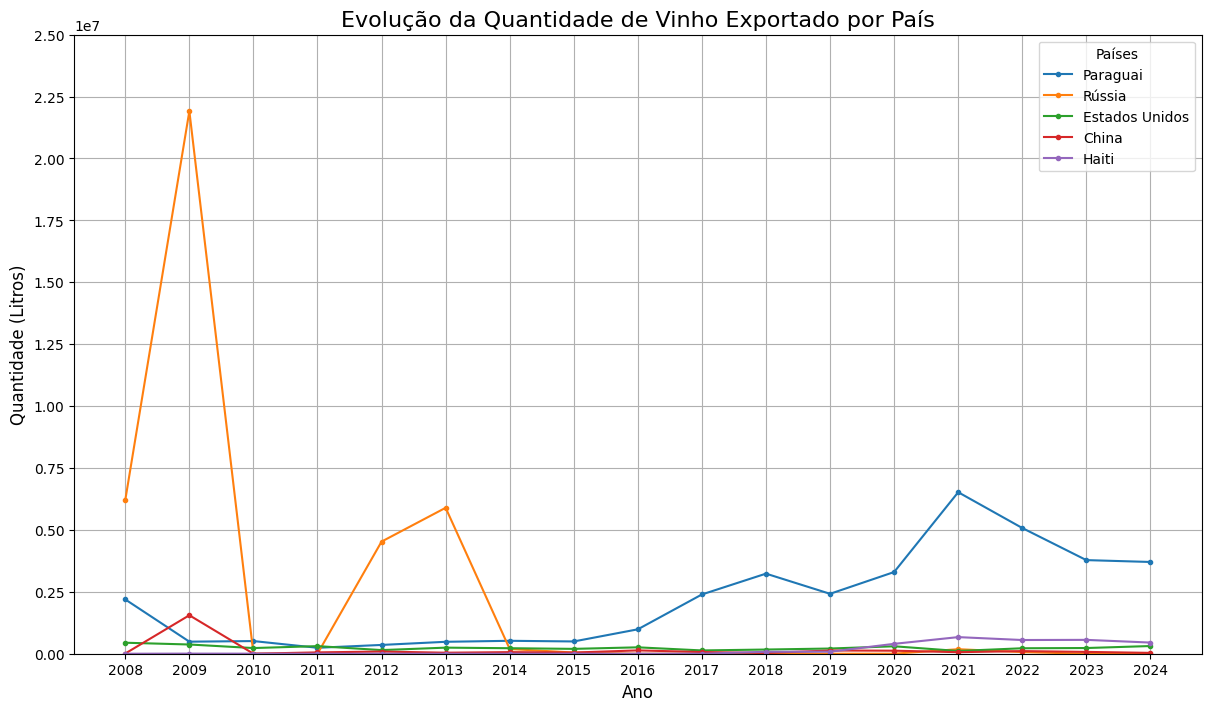

In [15]:
paises_para_plotar = ['Paraguai', 'Rússia', 'Estados Unidos', 'China', 'Haiti']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos (a "tela de pintura")
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['quantidade'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Evolução da Quantidade de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Litros)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 25_000_000)
ticks_person = np.arange(0, 25_000_001, 2_500_000) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

##Analises contextualizadas
motivos de queda da exportação em volume da russia:
*crise economica e valorizacao R$ x U$D, consequente mudanças na politica de importação
*entre 2011-14 - aumento do petroleo favoreceu economia da russia

comportamento Paraguai
*Distancia reduzida do polo produtor e consumidor
*O Paraguai tem uma carga tributária menor em comparação com o Brasil, o que torna os vinhos, tanto nacionais quanto importados, mais baratos para o consumidor final

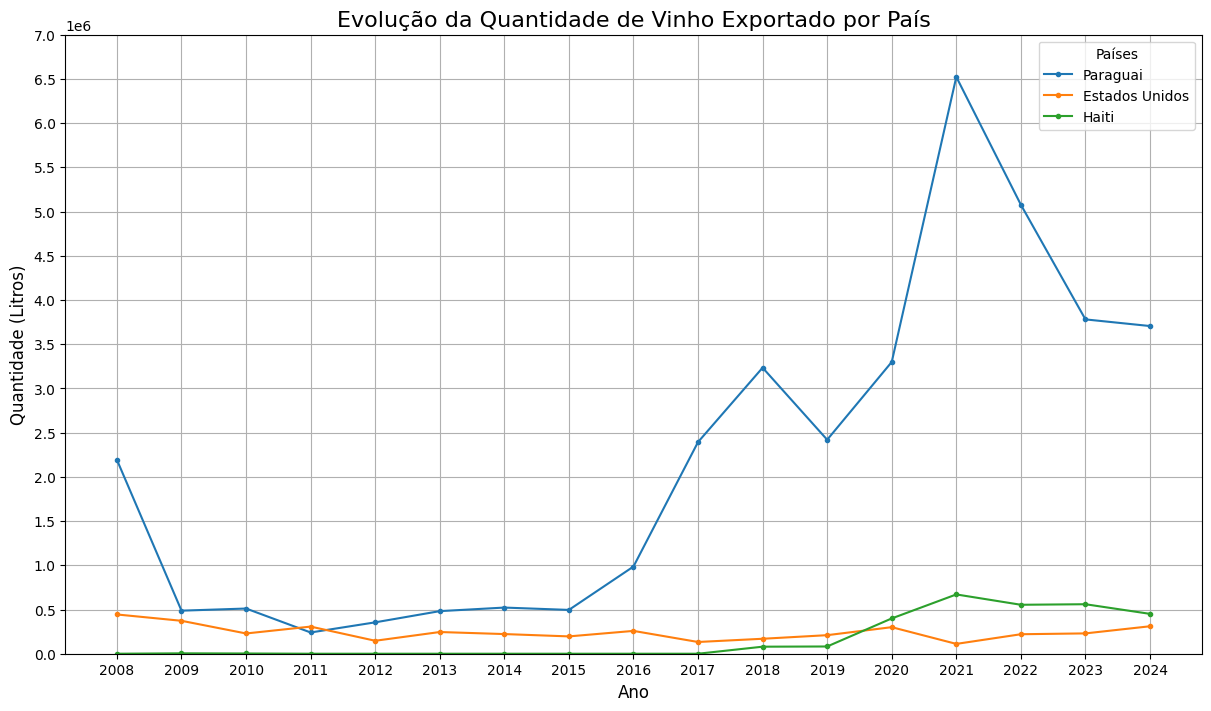

In [16]:
#plotando paises sem china e Russia para visualizar os menores

paises_para_plotar = ['Paraguai',  'Estados Unidos', 'Haiti']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos (a "tela de pintura")
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['quantidade'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Evolução da Quantidade de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Litros)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 7_000_000)
ticks_person = np.arange(0, 7_000_001, 500_000) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

##Analise contextualizada
Paraguai
*diminuição do consumo de 2020~
multifatorial e incerto
- flutuação cambial? - da pra checar
- preferencia do consumidor/comportamento
-concorrencia - vinhos chilenos e argentinos tem mais facilidade?

Haiti
- possui dois acordos comerciais que dificultam expansao (caricom - comunidade do Caribe) e EPA- parceria economica com os EUA...  tornam o eixo de comercio com certa vantagem para os Eua e caribenhos. Proporcionalmente como é Brasil e demais paises membros do Mercosul. Lembrando que Haiti nao possui nenhum acordo especifico para uvas ou vinhos.



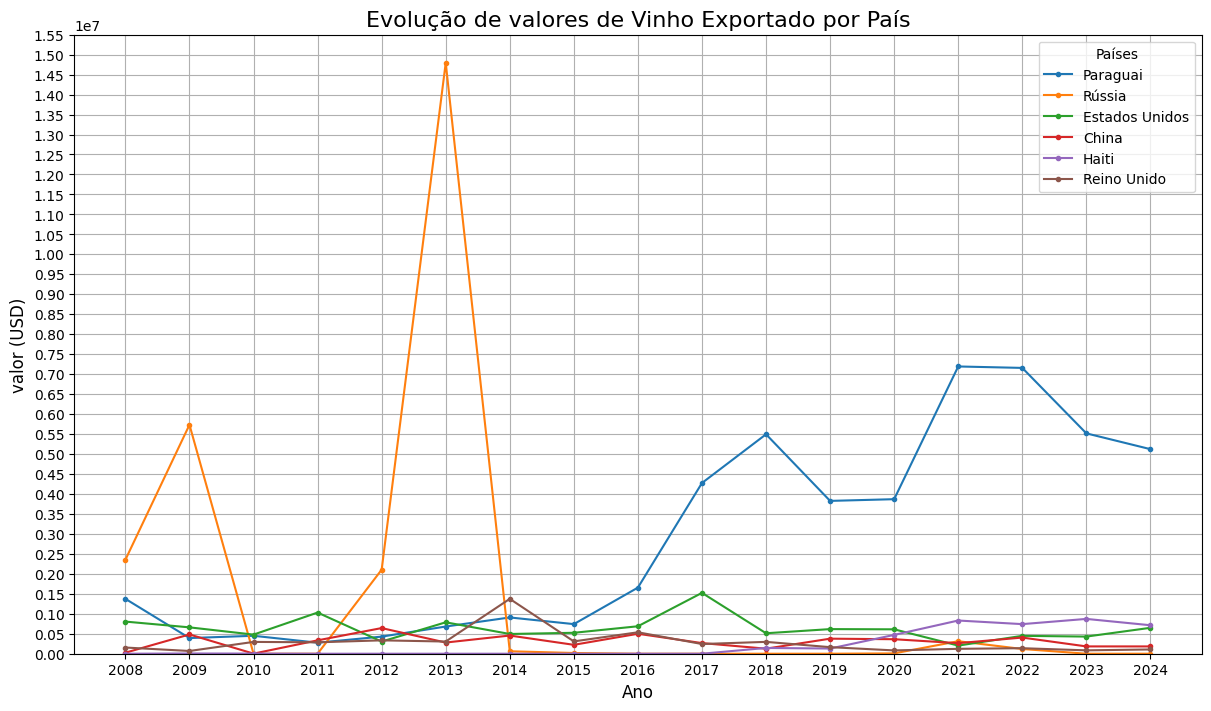

In [17]:
paises_para_plotar = ['Paraguai', 'Rússia', 'Estados Unidos', 'China', 'Haiti', 'Reino Unido']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 15_500_000)
ticks_person = np.arange(0, 15_500_001, 500_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

vale a pena fazer analise para o mercosul?

Nao houve destaques para estudos que viesse a trazer algum insight em vista de que os comercios de  Argentina, Uruguai, Chile e Paraguai sao inundados por vinhos europeus (França, Portugal, Italia, Espanha)

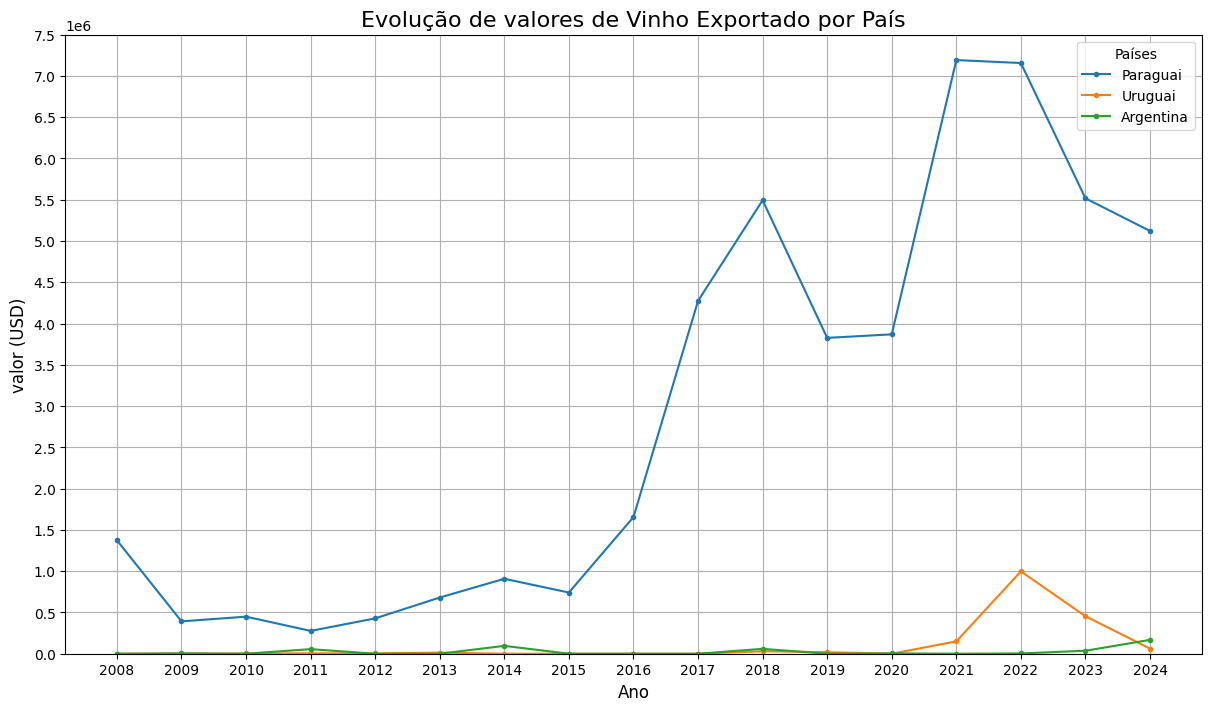

In [18]:
paises_para_plotar = ['Paraguai', 'Uruguai', 'Argentina']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 7_500_000)
ticks_person = np.arange(0, 7_500_001, 500_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

Analise para o Brics, vale a pena?
(acordo comercial entre os membros que não perpassam sobre o valor do dolar, diminuindo o desequilibrio cambial entre os participantes)
(Não pus Russia no gráfico porque fica distoante por tamanho muito grande)
India e Africa do Sul são inexpressivos, talvez por questoes culturais.
China e Rússia se destacam....

**pode vir a ser um bom mercado em vista de ter acordos comerciais que diminuem a desvantagem cambial **

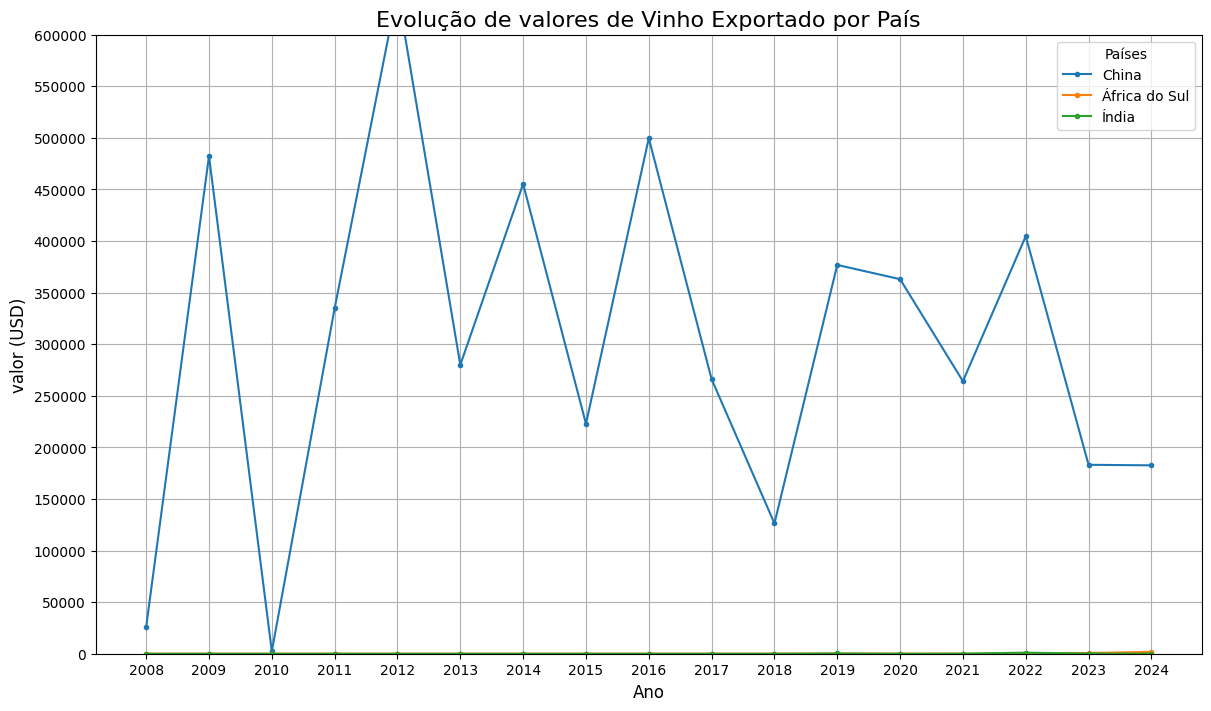

In [19]:
paises_para_plotar = ['China', 'África do Sul', 'Índia']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 600_000)
ticks_person = np.arange(0, 600_001, 50_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

nao sei dizer qual paga melhor pelo vinho importado china,russia ou paraguai


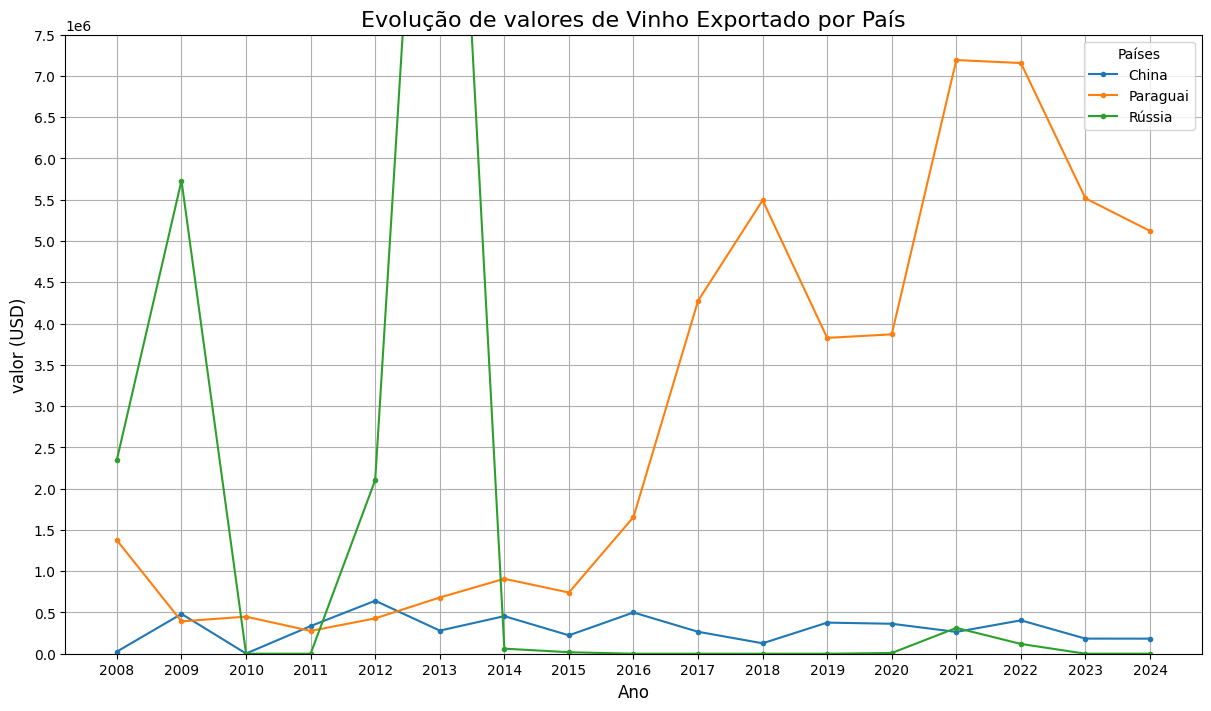

In [20]:
paises_para_plotar = ['China', 'Paraguai', 'Rússia']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 7_500_000)
ticks_person = np.arange(0, 7_500_001, 500_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

olhando para o paraguai

/tmp/ipython-input-21-3561364352.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


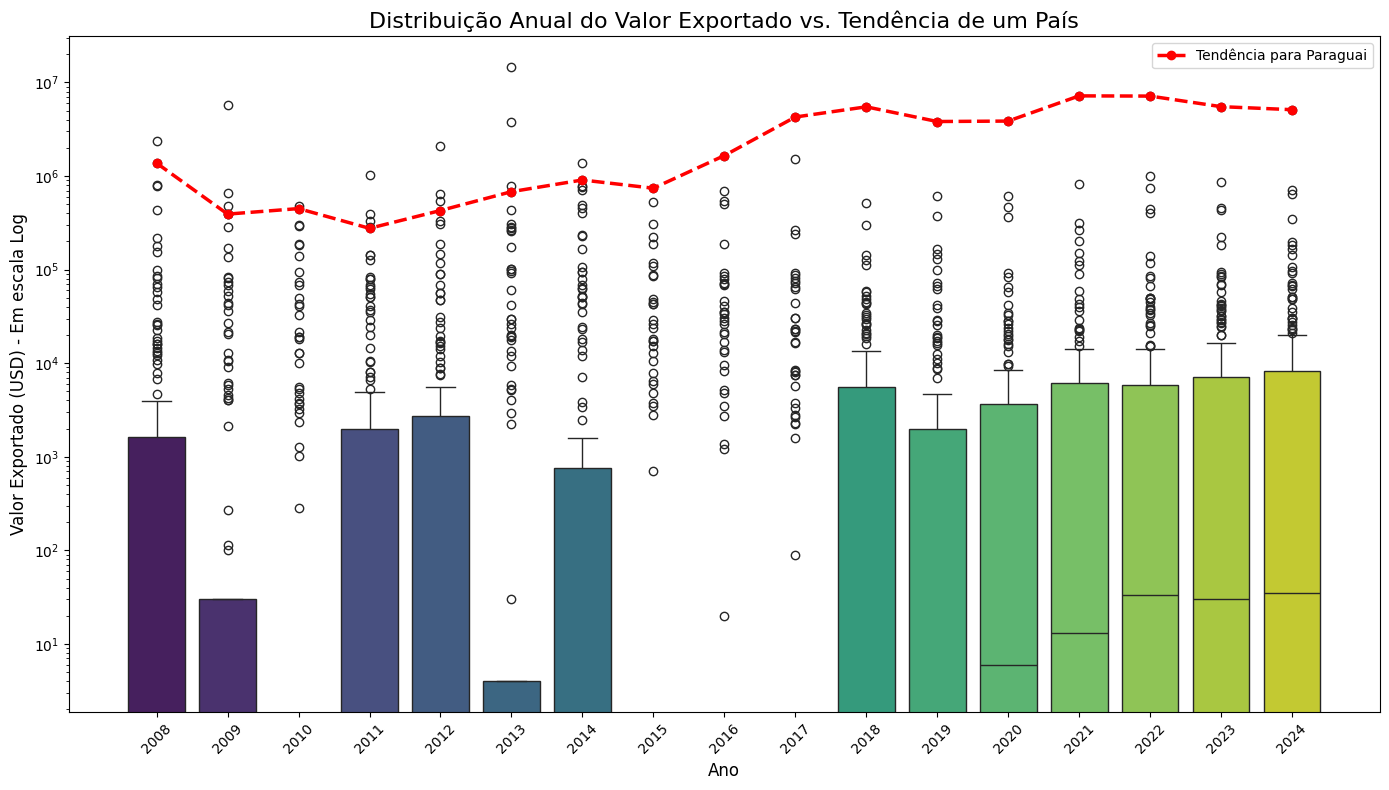

In [21]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Exportado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Paraguai'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()


olhando para China

/tmp/ipython-input-22-839853237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


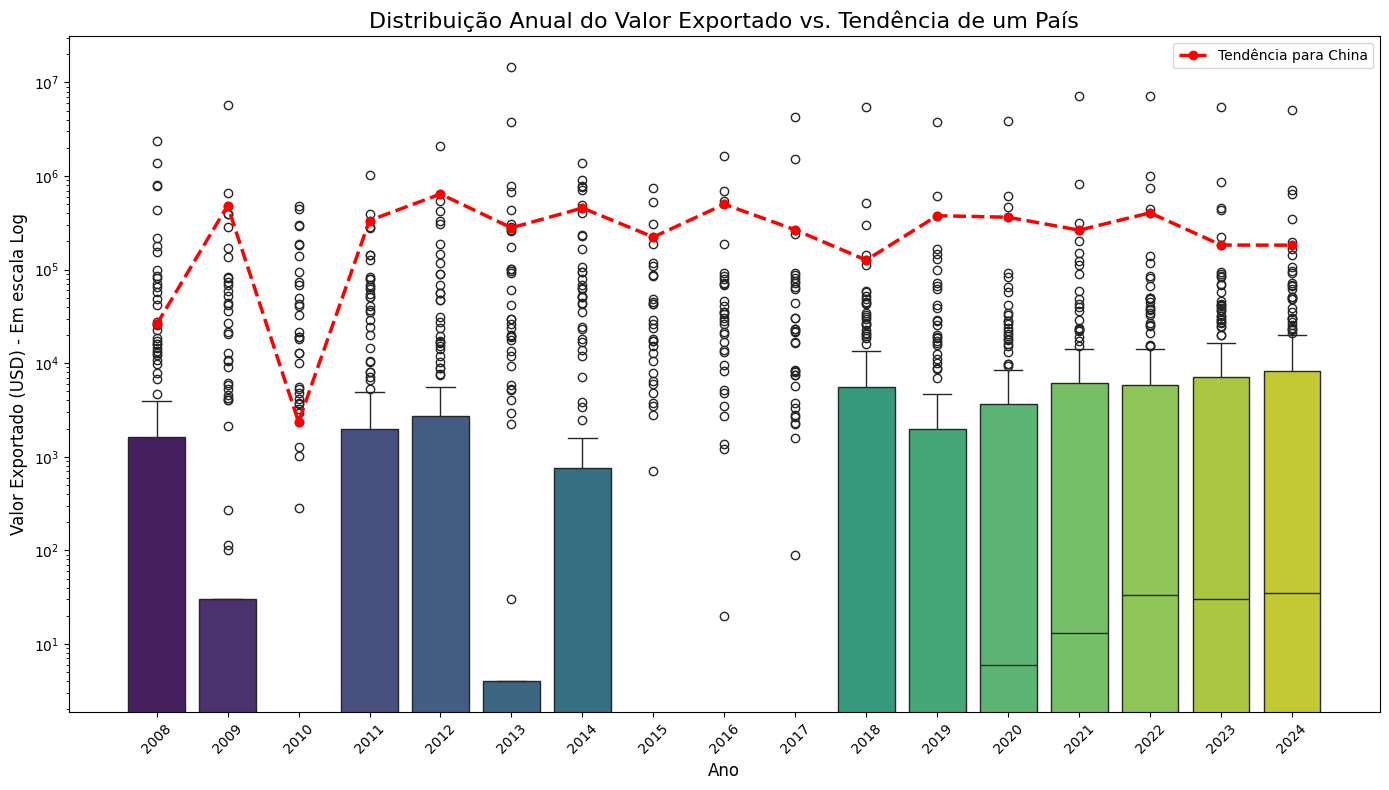

In [22]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Exportado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'China'
#____________________________

df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()


/tmp/ipython-input-23-2086363776.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


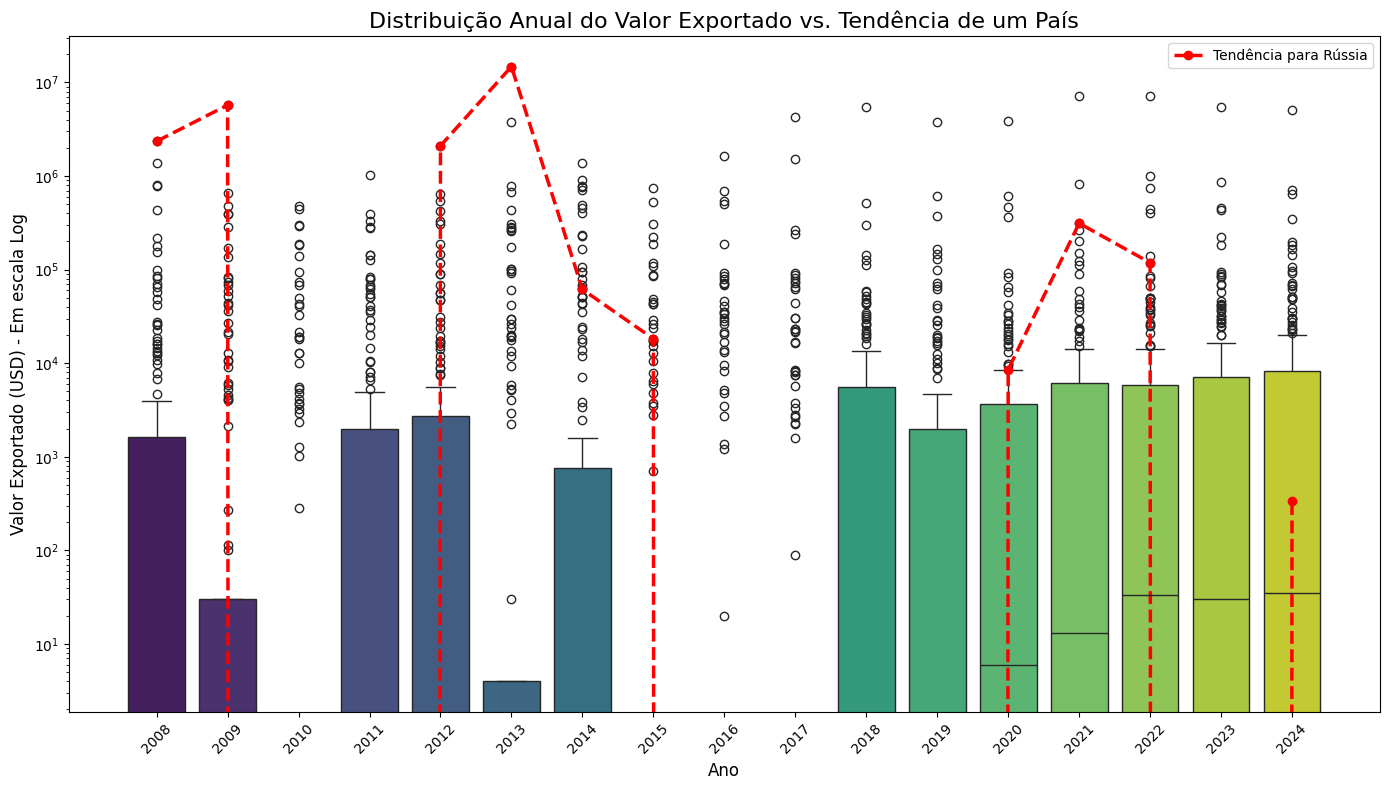

In [23]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Exportado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Rússia'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

# IMPORTAÇÃO DE VINHOS
================================================================================

In [24]:
df_imp_vinhos = pd.read_csv('ImpVinhosPivot.csv')
df_imp_vinhos.tail()

,Id,País,Ano,Quantidade,Valor (USD)
3790,69,Outros,2020,0,0
3791,69,Outros,2021,0,0
3792,69,Outros,2022,0,0
3793,69,Outros,2023,0,0
3794,69,Outros,2024,0,0


In [25]:
#renomeando colunas
df_imp_vinhos.columns = [ 'id', 'pais', 'ano', 'quantidade', 'valor']
df_imp_vinhos.drop('id', axis=1, inplace = True)

In [26]:
#verificando valores nulos
df_imp_vinhos.isnull().sum()

,0
pais,0
ano,0
quantidade,0
valor,0


In [27]:
#verificando tipo das features
df_imp_vinhos.dtypes


,0
pais,object
ano,int64
quantidade,int64
valor,int64


In [28]:
# Convertendo feature ano para tipo object
df_imp_vinhos['ano'] = df_imp_vinhos['ano'].astype(str)

In [29]:
#recorte dos último 15 anos (>2007), resetando index original
df_imp_vinhos_filtrado = df_imp_vinhos[df_imp_vinhos['ano'] > '2007'].reset_index()

In [30]:
#retirando pivot index
df_imp_vinhos_filtrado.drop('index', axis=1, inplace = True)

## Top5 maiores **volumes** exportados num único ano


Há um grande impacto de importação de vinho chileno no Brasil

*top15 é do Chile* e ainda se repete em #17 e #18

In [31]:
volume_imp = df_imp_vinhos_filtrado.sort_values(by='quantidade', ascending=False)
volume_imp.head(20)


,pais,ano,quantidade,valor
271,Chile,2024,73111416,199874777
267,Chile,2020,72726186,176540499
268,Chile,2021,69617587,182568098
269,Chile,2022,68881232,184335335
270,Chile,2023,62358765,170146247
266,Chile,2019,52697108,145471294
264,Chile,2017,51787643,145628860
265,Chile,2018,51104825,144731210
263,Chile,2016,43400991,123183079
262,Chile,2015,36686870,107684380


##Top5 maiores **valores** importados por ano

*Chile ainda se destaca como maior exportador, no entanto, Argentina contraria tendencia em valor em 2024, ou seja, Chile ocupou maior volume, mas Argentina ocupou maior valor em 2024. Em outras palavras, aparente Vinho argentino seja mais caro em 2024 que o chileno.*

In [32]:
volume_imp = df_imp_vinhos_filtrado.sort_values(by='valor', ascending=False)
volume_imp.head(20)

,pais,ano,quantidade,valor
271,Chile,2024,73111416,199874777
269,Chile,2022,68881232,184335335
268,Chile,2021,69617587,182568098
267,Chile,2020,72726186,176540499
270,Chile,2023,62358765,170146247
264,Chile,2017,51787643,145628860
266,Chile,2019,52697108,145471294
265,Chile,2018,51104825,144731210
263,Chile,2016,43400991,123183079
261,Chile,2014,35479279,113375484


## Top5 maiores importadores por valor acumulados nos últimos 15 anos

Chile e Argentina se destacam como maiores parceiros em valores.
Chama atenção os vinhos europeus (Portugal, Itálica. França e Espanha) - evidencias que a cultura de importação de vinhos tradicionais europeus se repetem no Brasil como na America do Sul

**Africa do Sul** o país que não importa do Brasil mas exporta para ele... verificar exportação de uva para africa do sul

Autralia, pais que nem aparece como exportado mas aparece vendendo vinho pra Brasil


In [33]:
imp_valor = df_imp_vinhos_filtrado.groupby(['pais'])['valor'].sum()
imp_valor.sort_values(ascending=False).head(10)

,valor
pais,
Chile,2147201311
Argentina,1009344018
Portugal,792685704
Itália,534761465
França,397753680
Espanha,249896908
Uruguai,104466204
Africa do Sul,42325905
Estados Unidos,40848493


### Análise exploratória dos dados

##ANÁLISE POR VOLUME

Considerações:

***analise por volume pode indicar preferencia do mercado por qualidade OU PORQUE É MAIS BARATO?
***

Filtrado o top6 de maiores importadores **por volume**
corrobora pela tese de vinhos europeus tradicionais inundam o mercado sulamericano. O grande concorrente é o vinho chileno Porque? - mais barato? mais perto? por que vantajoso?

Há uma boa equiparação de vinho portugues e Argentino

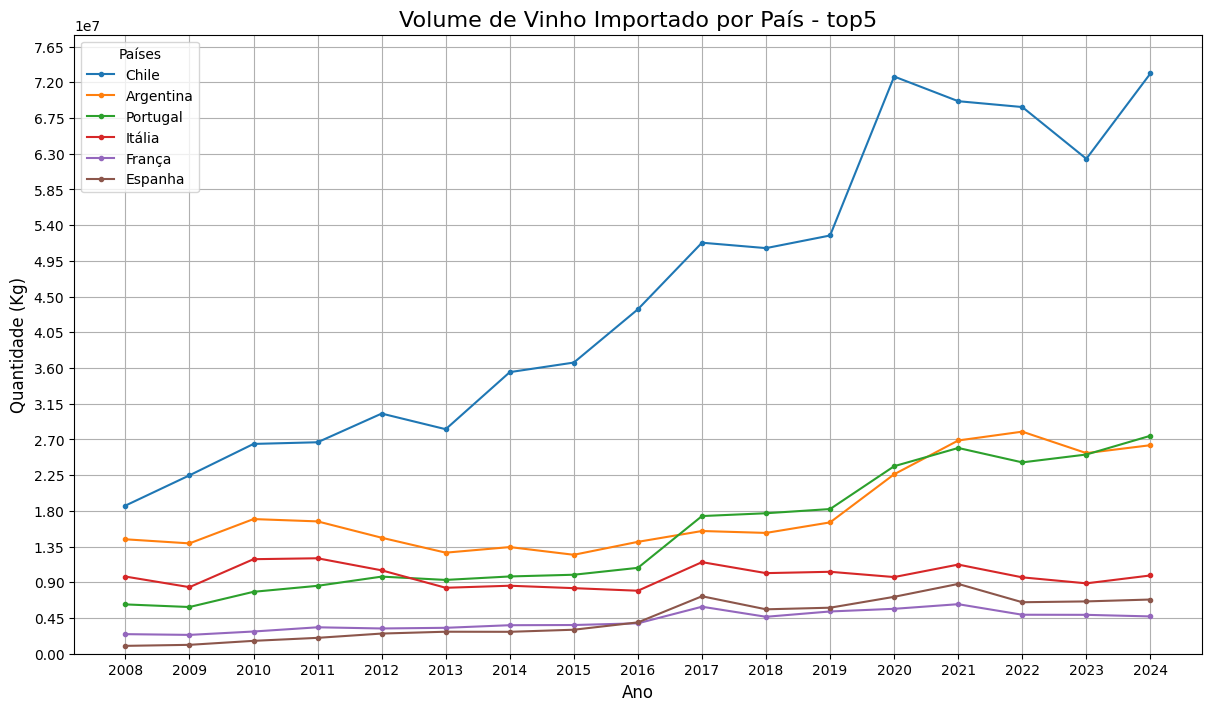

In [34]:
paises_para_plotar = ['Chile', 'Argentina', 'Portugal', 'Itália', 'França', 'Espanha']
df_imp_vinho_analise = df_imp_vinhos_filtrado[ df_imp_vinhos_filtrado['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_imp_vinho_analise[df_imp_vinho_analise['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['quantidade'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Volume de Vinho Importado por País - top5', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Kg)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 78_000_000)
ticks_person = np.arange(0, 78_000_001, 4_500_000) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

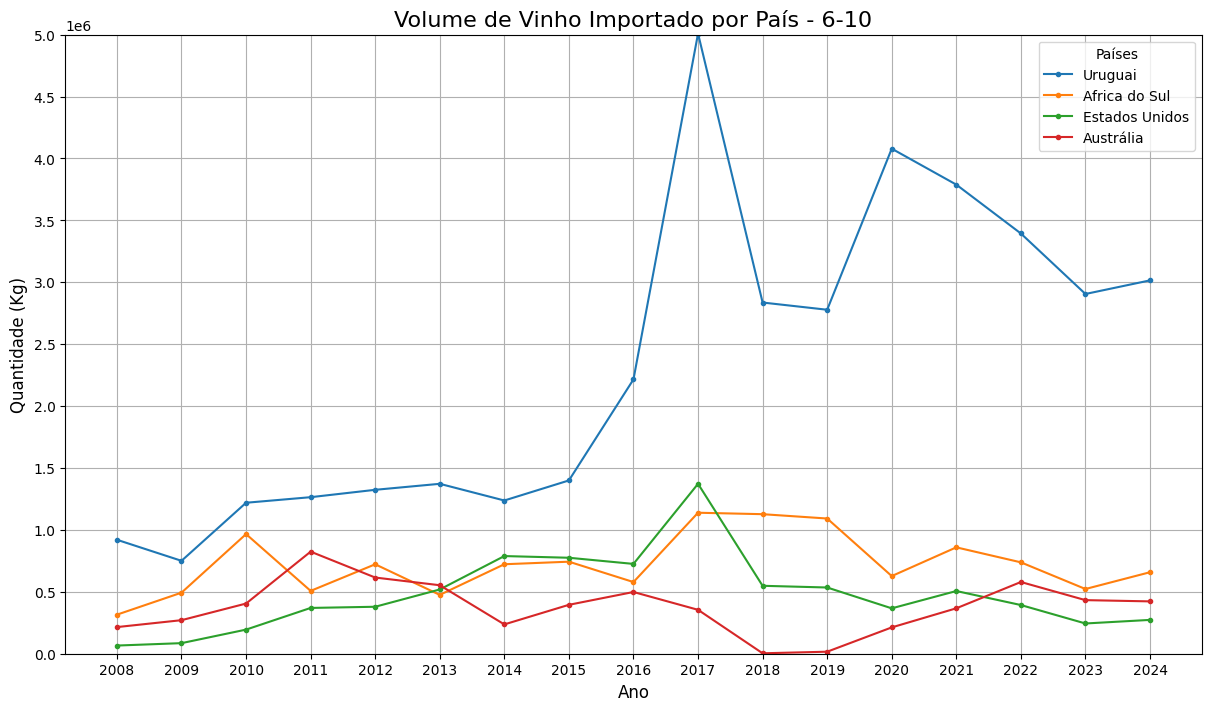

In [35]:
paises_para_plotar = [ 'Uruguai', 'Africa do Sul', 'Estados Unidos', 'Austrália']
df_imp_vinho_analise = df_imp_vinhos_filtrado[ df_imp_vinhos_filtrado['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_imp_vinho_analise[df_imp_vinho_analise['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['quantidade'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Volume de Vinho Importado por País - 6-10', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Kg)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 5_000_000)
ticks_person = np.arange(0, 5_000_001, 500_000) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

Onde está o BRICS nisso?

Destaque de importação: África do Sul
porque?

Variedade:
A África do Sul produz uma ampla gama de vinhos, tanto tintos quanto brancos, com destaque para a uva Pinotage, uma variedade tinta única da região.
Qualidade:
Os vinhos sul-africanos são conhecidos por sua intensidade, riqueza de sabores e aromas, e por sua capacidade de envelhecimento.
Custo-benefício:
Muitos vinhos sul-africanos são considerados ótimos achados em termos de preço, oferecendo vinhos de alta qualidade a preços acessíveis.

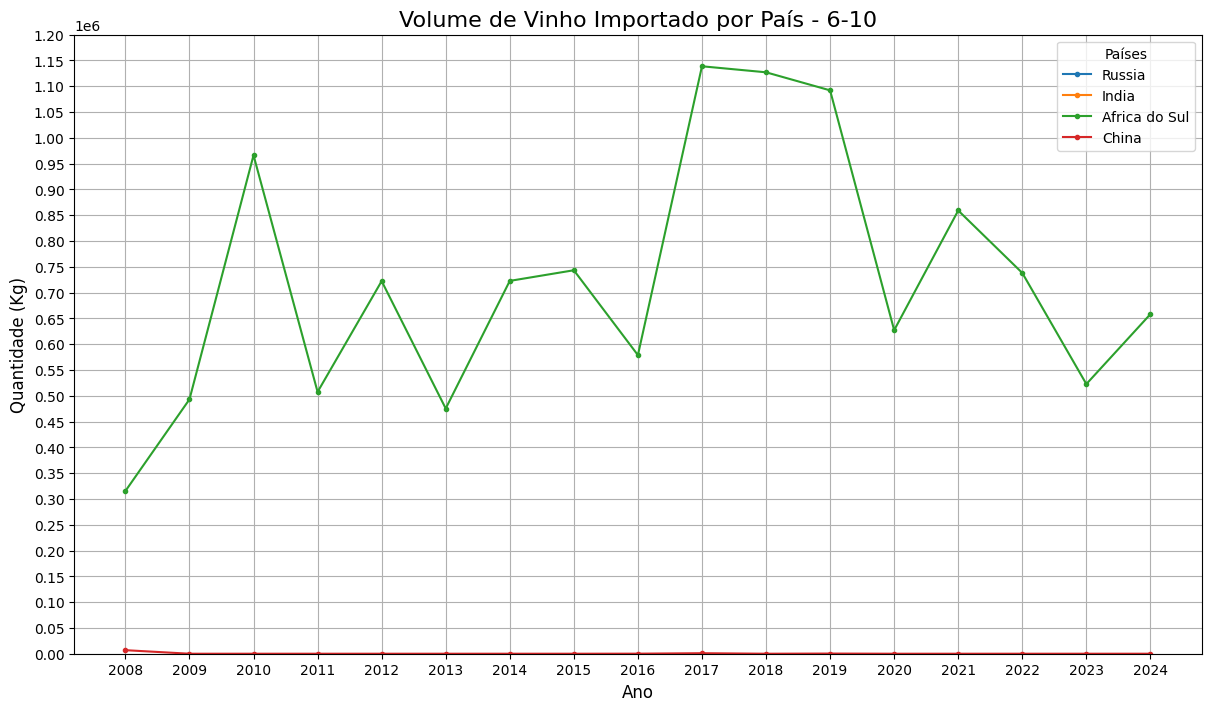

In [38]:
paises_para_plotar = [ 'Russia', 'India', 'Africa do Sul', 'China']
df_imp_vinho_analise = df_imp_vinhos_filtrado[ df_imp_vinhos_filtrado['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_imp_vinho_analise[df_imp_vinho_analise['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['quantidade'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Volume de Vinho Importado por País - 6-10', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Kg)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 1_200_000)
ticks_person = np.arange(0, 1_200_001, 50_000) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

## ANALISE POR VALOR

Análise valor dos top6
Espanha teve um pico entre 2009 e 2012.

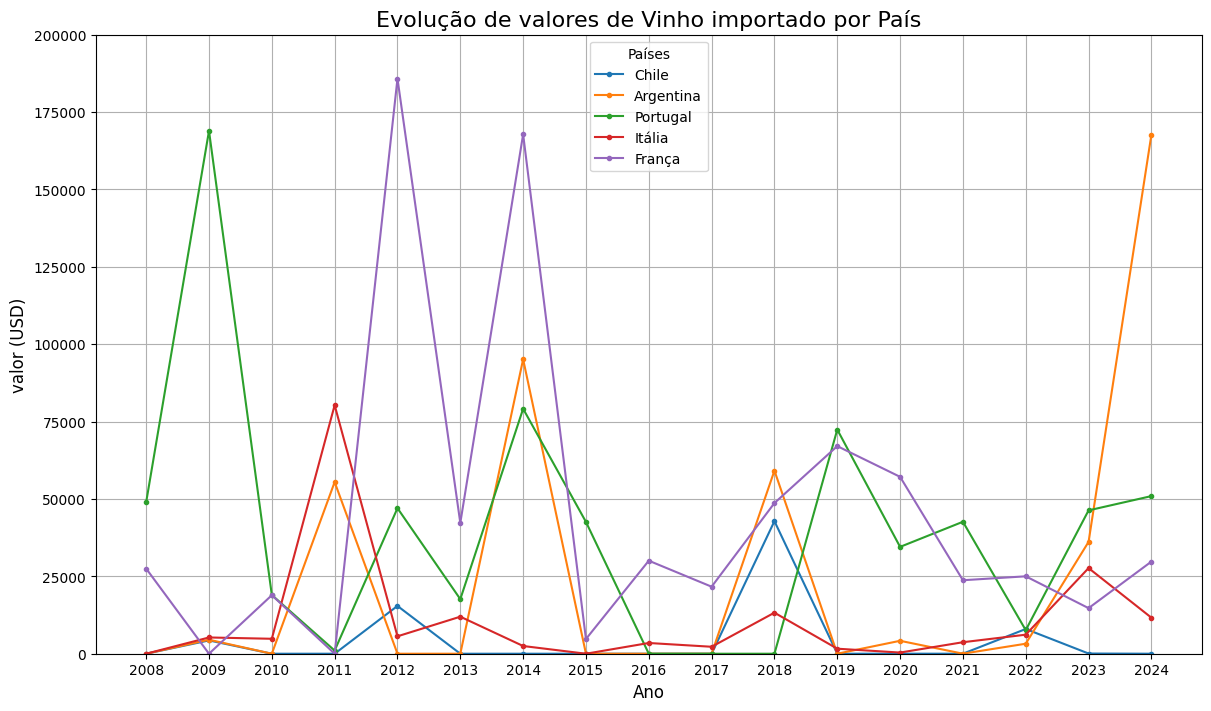

In [50]:
paises_para_plotar = ['Chile', 'Argentina', 'Portugal', 'Itália', 'França', ]
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho importado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 200_000)
ticks_person = np.arange(0, 200_001, 25_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

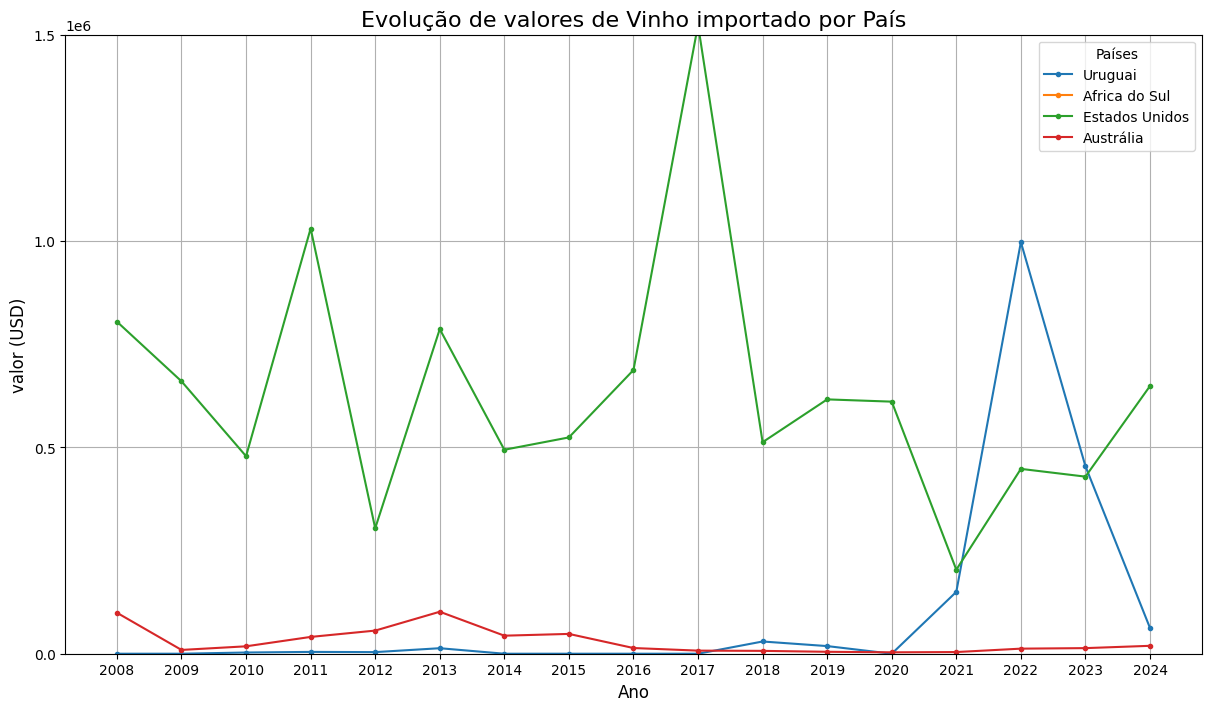

In [53]:
paises_para_plotar = ['Uruguai', 'Africa do Sul', 'Estados Unidos', 'Austrália' ]
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho importado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 1_500_000)
ticks_person = np.arange(0, 1_500_001, 500_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

# Tendência dos paises destaques

Chile

/tmp/ipython-input-54-3992668917.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


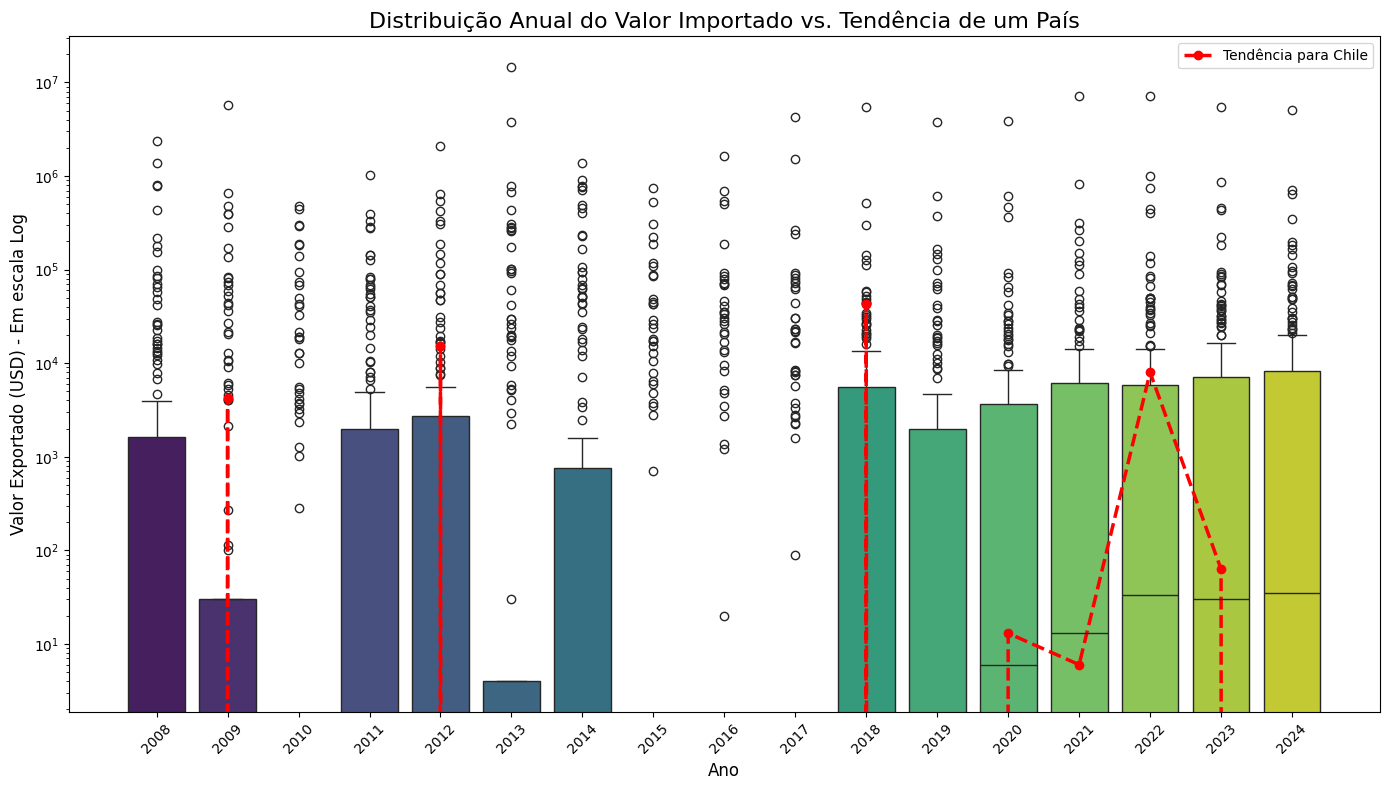

In [54]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Chile'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

Argentina

/tmp/ipython-input-55-1790345536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


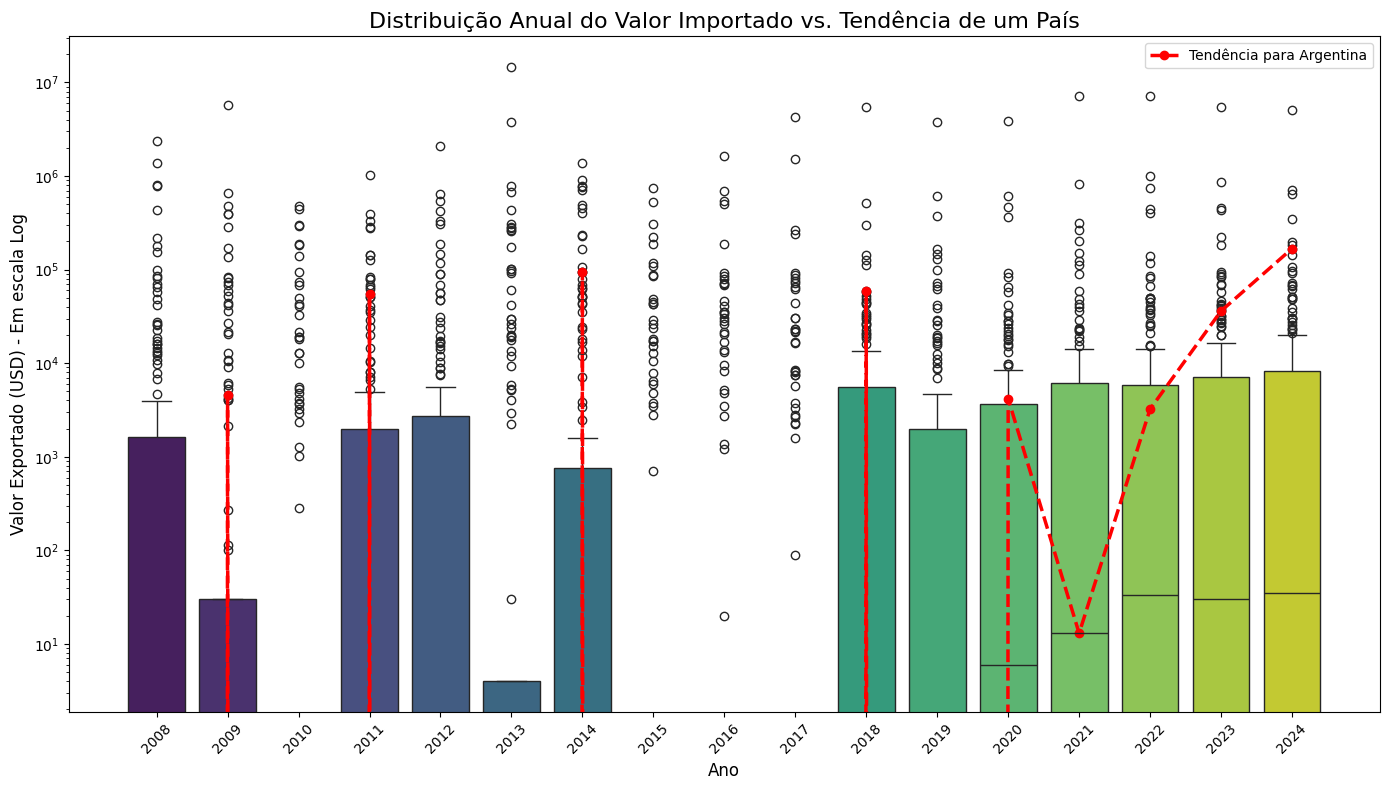

In [55]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Argentina'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

Portugal

/tmp/ipython-input-56-2011366938.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


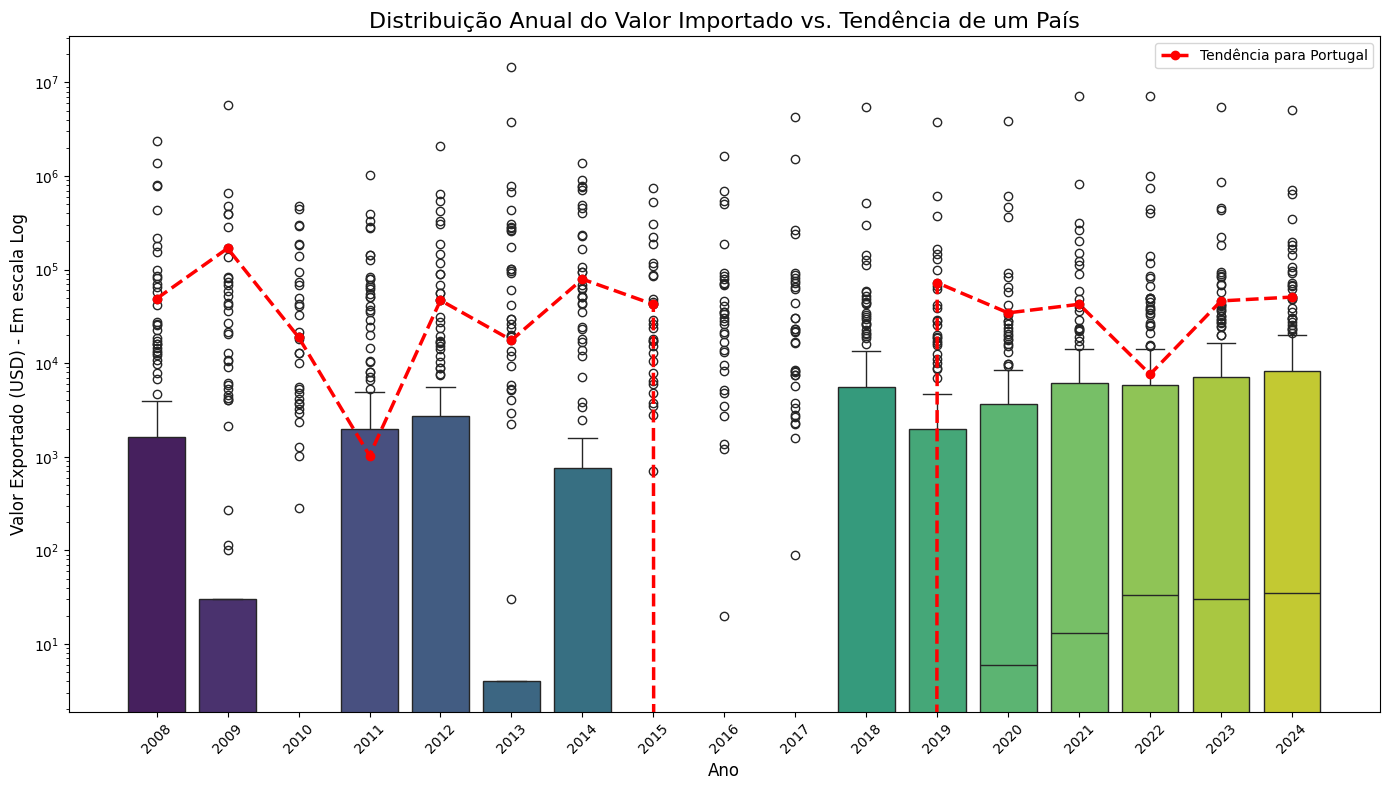

In [56]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Portugal'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

Itália

/tmp/ipython-input-57-2091745975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


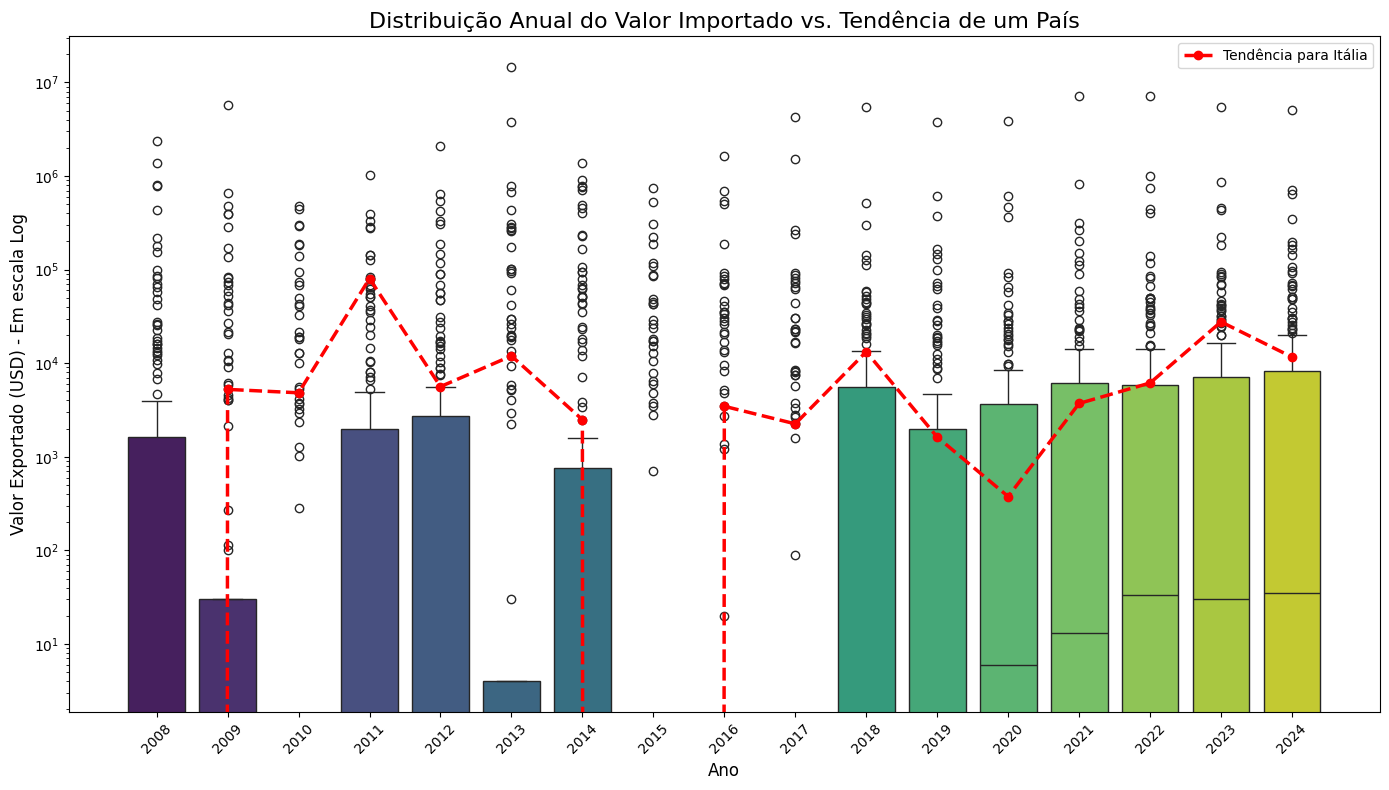

In [57]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Itália'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

França


/tmp/ipython-input-58-1907593198.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


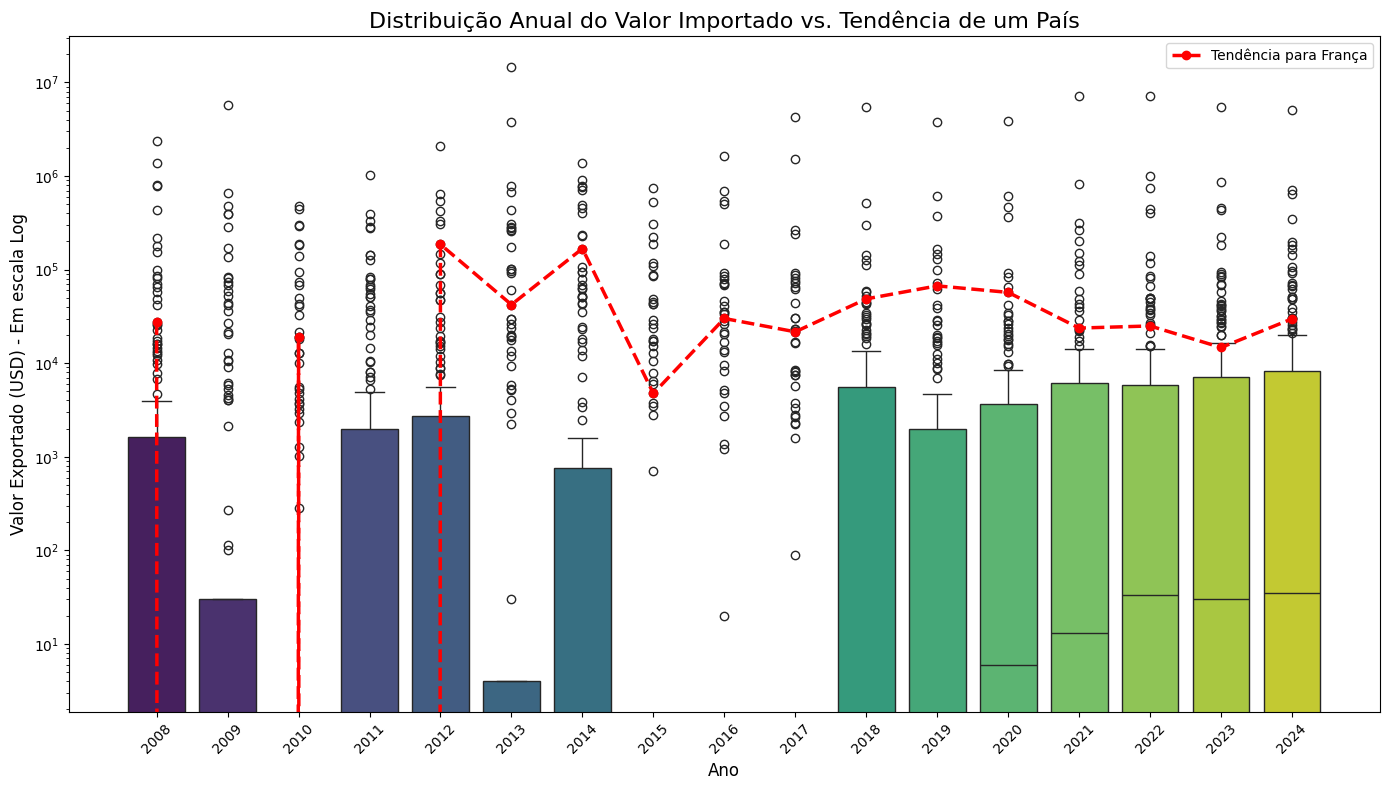

In [58]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'França'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

Espanha

/tmp/ipython-input-59-45528646.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


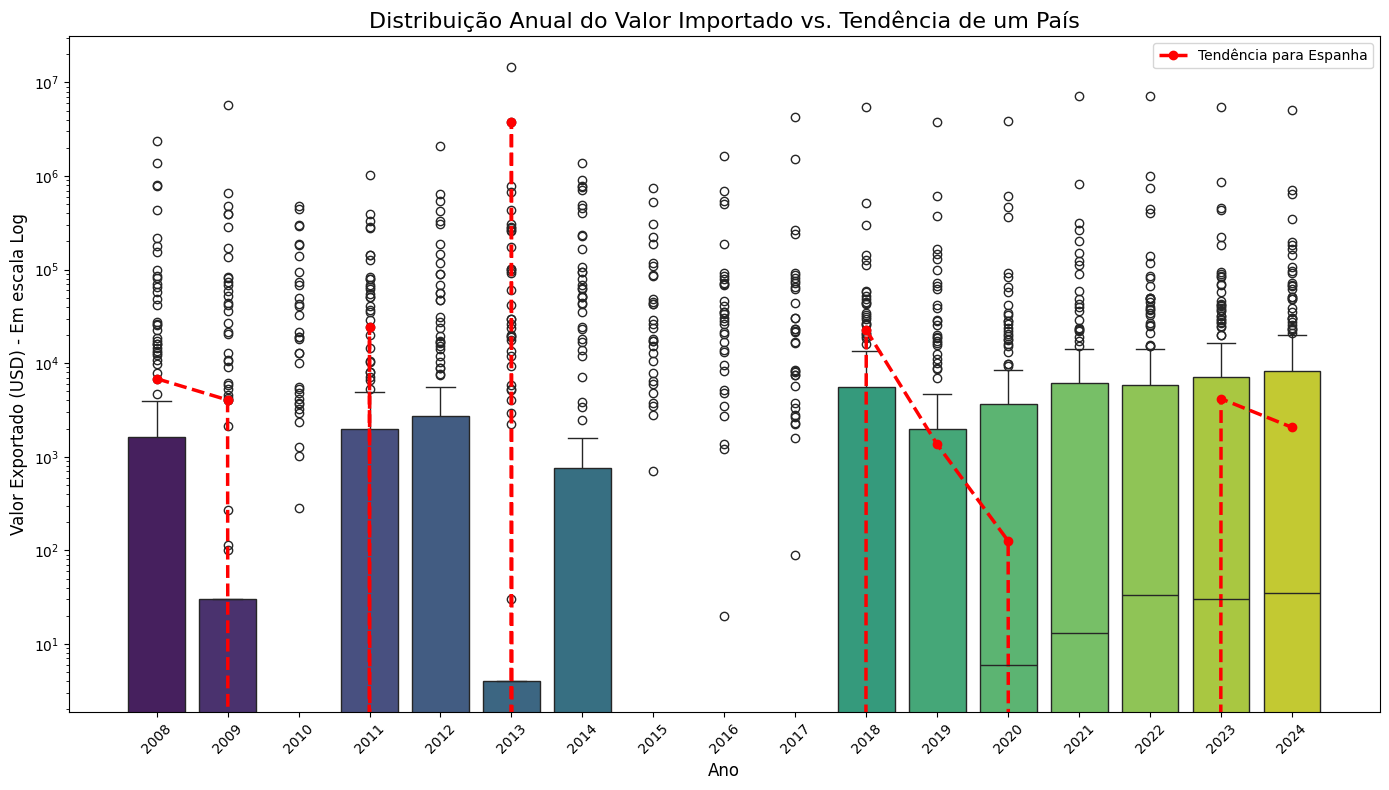

In [59]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Espanha'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

Uruguai

/tmp/ipython-input-60-2780600451.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


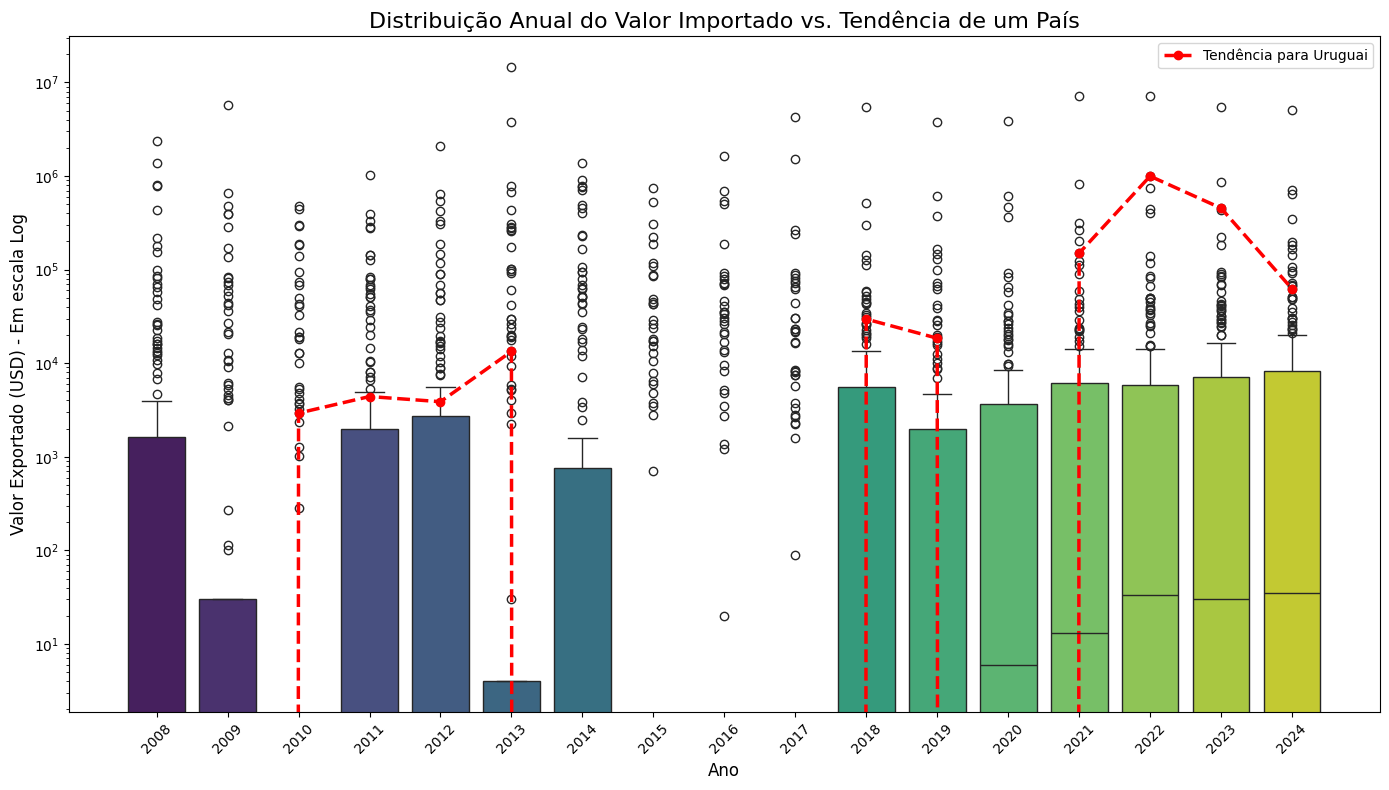

In [60]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Uruguai'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

Africa do Sul
nao tem nem tendencia rs.

/tmp/ipython-input-63-1569558105.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


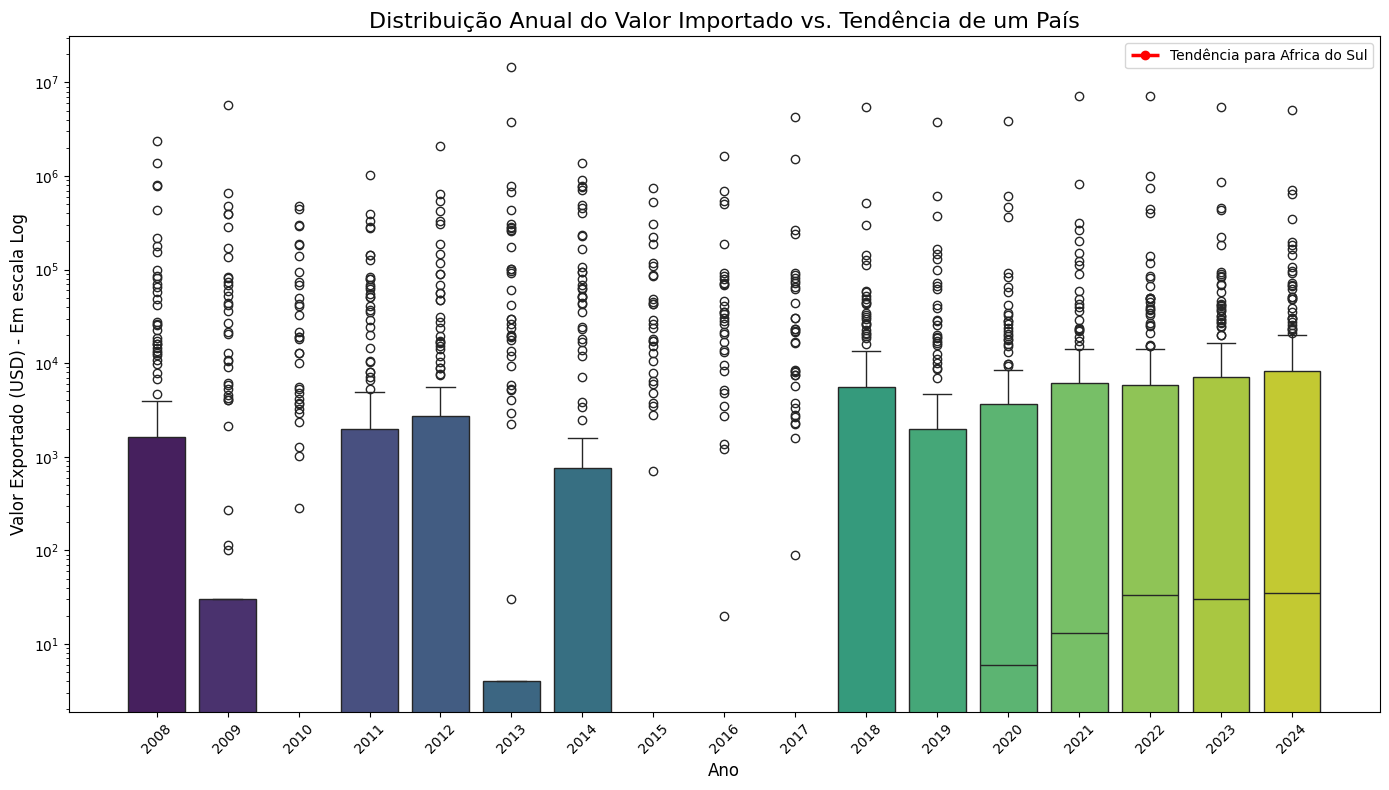

In [63]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Africa do Sul'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

Estados unidos


/tmp/ipython-input-64-3341706949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


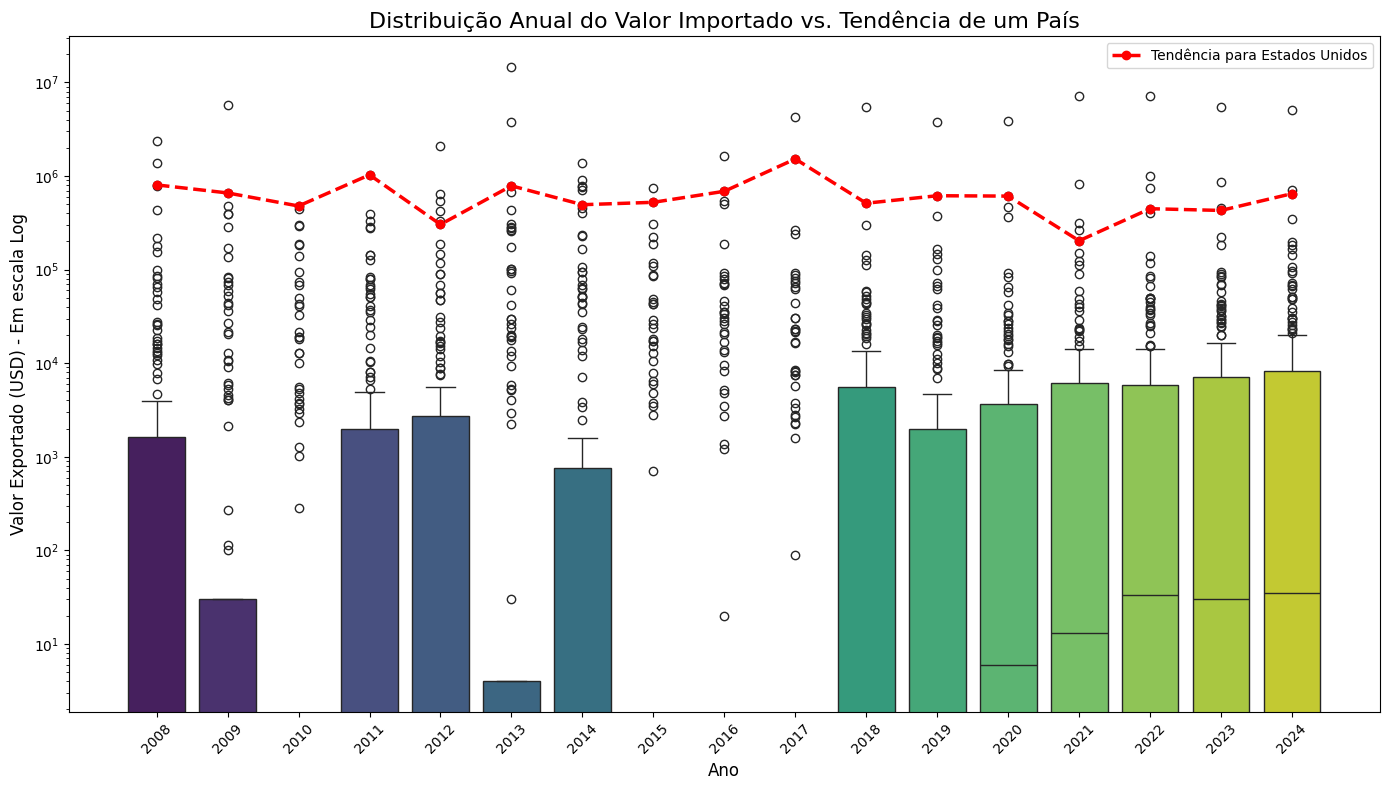

In [64]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Estados Unidos'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()

Austrália

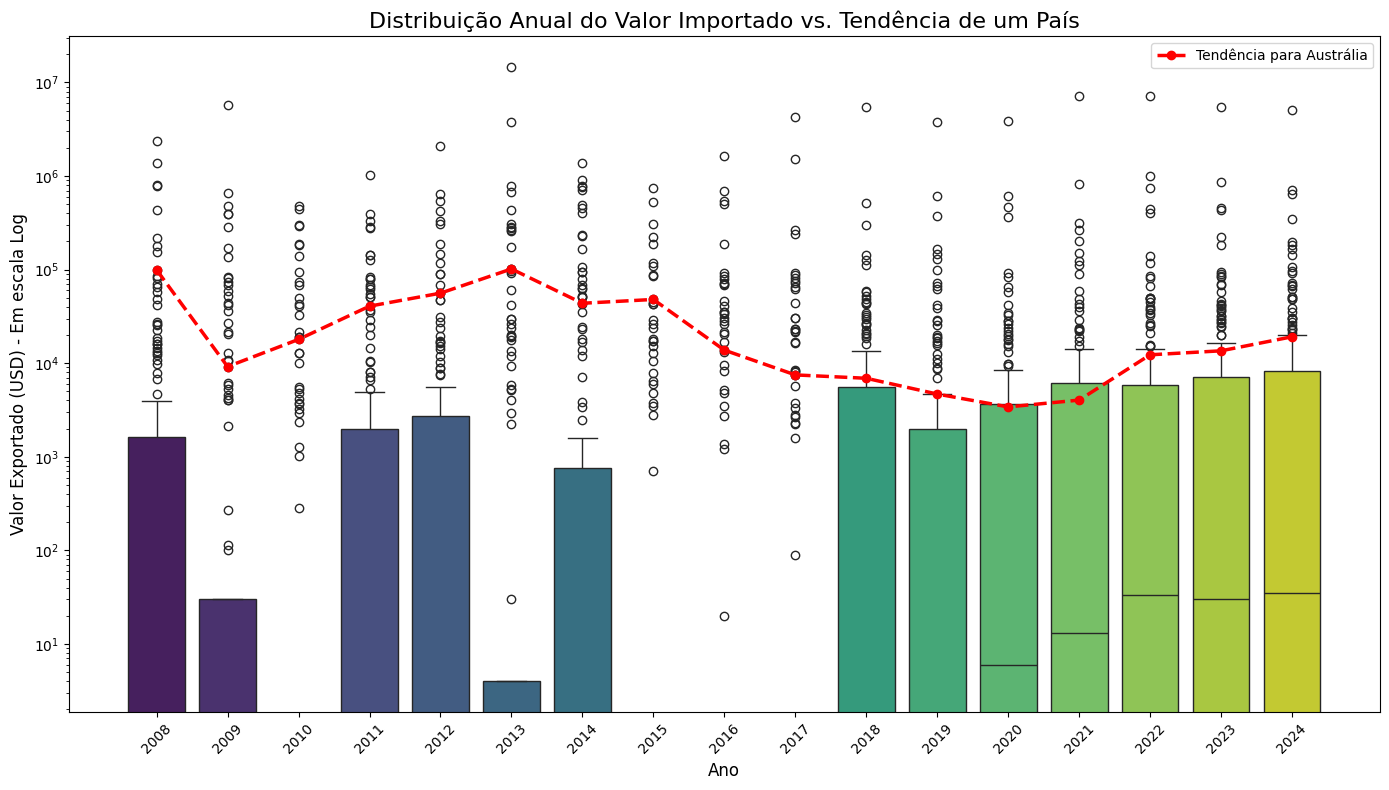

In [65]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Importado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Austrália'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()